# Lesson 3 — Relationships Between Variables

**Probability, Statistics, and Econometrics for Finance, Accounting, and Economics**  
Campbell University — Lundy-Fetterman School of Business  
Matthew L. Kelly, Ph.D.

This lecture studies how variables move together. In Lesson 1, we described individual random variables and distributions. In Lesson 2, we used probability models to test hypotheses. In Lesson 3, we move from **one variable at a time** to **relationships among variables**.

The central questions are:

1. Do two variables move together?
2. How strong is the relationship?
3. Does the relationship survive after conditioning on another variable?
4. When does correlation fail to describe dependence adequately?
5. How does this lead naturally to regression analysis?

## Position in the 7-Lecture Series

1. **Distributions and descriptive statistics**: moments, random variables, PDFs/CDFs, entropy, convergence.
2. **Hypothesis testing and experimental design**: test statistics, $p$-values, power, assumptions.
3. **Relationships between variables**: covariance, correlation, conditional dependence, partial correlation, copulas, and first regression ideas.
4. **Linear regression and OLS**: estimation, fitted values, residuals, goodness of fit.
5. **Multiple regression and causal interpretation**: controls, omitted variables, dummy variables, interactions.
6. **Time series and financial data**: stationarity, autocorrelation, returns, volatility.
7. **Applied econometric modeling**: model selection, diagnostics, forecasting, and communication of results.

Today’s lecture is the bridge between probability and econometrics. Regression is, at root, a disciplined way to describe conditional relationships among variables.

## Learning Objectives

By the end of this lecture, students should be able to:

- compute and interpret covariance and correlation;
- explain why correlation is scale-free but covariance is not;
- distinguish unconditional from conditional relationships;
- compute correlation by subgroup or market state;
- explain partial correlation as correlation after removing the effect of controls;
- understand why dependence may be nonlinear or concentrated in the tails;
- describe the basic idea of a copula;
- derive simple ordinary least squares as a covariance-based relationship.

In [1]:
# Core imports for the lecture
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Reproducibility
rng = np.random.default_rng(42)

# Plot defaults
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

# 1. Covariance

Suppose $X$ and $Y$ are two random variables. Their covariance is

$$
\operatorname{Cov}(X,Y) = \mathbb{E}\left[(X-\mu_X)(Y-\mu_Y)\right],
$$

where

$$
\mu_X = \mathbb{E}[X]
\quad \text{and} \quad
\mu_Y = \mathbb{E}[Y].
$$

Covariance measures whether deviations from the mean tend to move together.

- If $X$ is above its mean when $Y$ is above its mean, covariance tends to be positive.
- If $X$ is above its mean when $Y$ is below its mean, covariance tends to be negative.
- If there is no systematic co-movement, covariance is near zero.

For a sample of $n$ observations, the sample covariance is

$$
s_{XY} = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}).
$$

In [3]:
# Generate two related variables
n = 1000
X = rng.normal(0, 1, n)
Y = 2 * X + rng.normal(0, 1, n)

# Sample covariance
covariance = np.cov(X, Y, ddof=1)[0, 1]
print(f"Covariance between X and Y: {covariance:.3f}")

Covariance between X and Y: 1.949


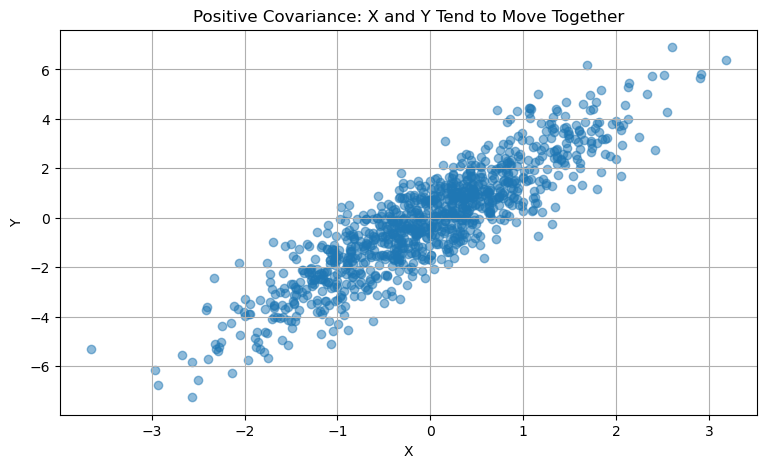

In [5]:
plt.scatter(X, Y, alpha=0.5)
plt.title("Positive Covariance: X and Y Tend to Move Together")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

## Covariance Matrix

A covariance matrix organizes variances and covariances in one object:

$$
\Sigma =
\begin{bmatrix}
\operatorname{Var}(X) & \operatorname{Cov}(X,Y) \\
\operatorname{Cov}(Y,X) & \operatorname{Var}(Y)
\end{bmatrix}.
$$

The diagonal terms are variances. The off-diagonal terms are covariances.

In finance, the covariance matrix is fundamental because portfolio variance depends on both individual asset variances and cross-asset covariances.

In [7]:
cov_matrix = np.cov(X, Y, ddof=1)
print("Covariance matrix:")
print(pd.DataFrame(cov_matrix, index=["X", "Y"], columns=["X", "Y"]))

Covariance matrix:
          X         Y
X  0.978550  1.949178
Y  1.949178  4.911806


# 2. Correlation

Covariance is useful, but its units depend on the units of $X$ and $Y$. Correlation standardizes covariance:

$$
\rho_{XY} = \frac{\operatorname{Cov}(X,Y)}{\sigma_X \sigma_Y}.
$$

The sample Pearson correlation is

$$
r_{XY} = \frac{s_{XY}}{s_X s_Y}.
$$

Correlation always lies between $-1$ and $1$:

$$
-1 \leq r_{XY} \leq 1.
$$

Interpretation:

- $r_{XY} = 1$: perfect positive linear relationship.
- $r_{XY} = -1$: perfect negative linear relationship.
- $r_{XY} = 0$: no linear relationship.

The phrase **linear relationship** matters. Correlation can miss nonlinear dependence.

In [9]:
correlation = np.corrcoef(X, Y)[0, 1]
print(f"Pearson correlation between X and Y: {correlation:.3f}")

Pearson correlation between X and Y: 0.889


## Why Correlation is Not the Same Thing as Causation

A positive correlation between $X$ and $Y$ does not by itself tell us that $X$ causes $Y$.

There are at least three possibilities:

1. $X$ causes $Y$.
2. $Y$ causes $X$.
3. Some omitted variable $Z$ affects both $X$ and $Y$.

The omitted-variable problem is central in econometrics. We will return to it repeatedly when we study regression.

# 3. Conditioning on Groups

Many relationships are not stable across groups, regimes, or states of the world. A correlation measured across the whole dataset is an **unconditional correlation**. A correlation measured within a group is a **conditional correlation**.

For example, in finance, two assets may have modest correlation during normal periods but high correlation during crises. This is exactly when diversification may fail.

In [11]:
# Simulate two variables whose relationship differs by state
n = 600
state = rng.choice(["Normal", "Crisis"], size=n, p=[0.75, 0.25])

asset_a = rng.normal(0.01, 0.03, n)
asset_b = np.empty(n)

# Lower dependence in normal times; higher dependence in crisis
normal = state == "Normal"
crisis = state == "Crisis"
asset_b[normal] = 0.20 * asset_a[normal] + rng.normal(0.008, 0.025, normal.sum())
asset_b[crisis] = 0.90 * asset_a[crisis] + rng.normal(-0.015, 0.015, crisis.sum())

returns = pd.DataFrame({"Asset A": asset_a, "Asset B": asset_b, "State": state})

overall_corr = returns[["Asset A", "Asset B"]].corr().iloc[0, 1]
state_corr = returns.groupby("State")[["Asset A", "Asset B"]].corr().iloc[0::2, -1]

print(f"Overall correlation: {overall_corr:.3f}\n")
print("Correlation by market state:")
print(state_corr)

Overall correlation: 0.443

Correlation by market state:
State          
Crisis  Asset A    0.891264
Normal  Asset A    0.260596
Name: Asset B, dtype: float64


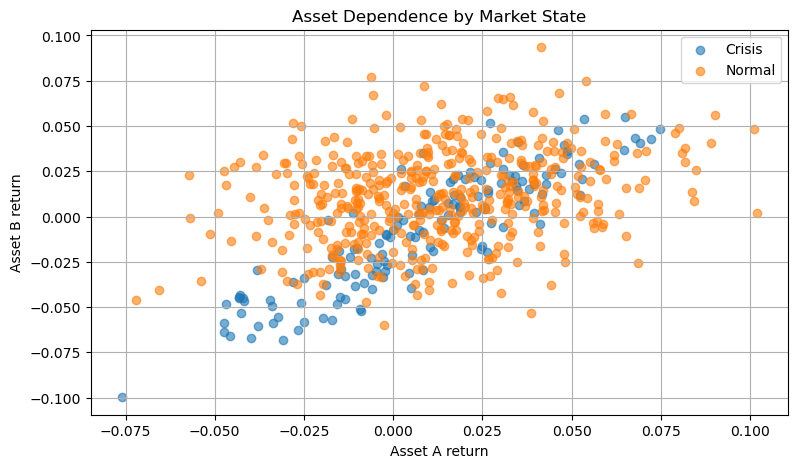

In [13]:
fig, ax = plt.subplots()
for label, group in returns.groupby("State"):
    ax.scatter(group["Asset A"], group["Asset B"], alpha=0.6, label=label)
ax.set_title("Asset Dependence by Market State")
ax.set_xlabel("Asset A return")
ax.set_ylabel("Asset B return")
ax.legend()
plt.show()

## Conditional Covariance

Conditional covariance asks how $X$ and $Y$ move together after conditioning on a variable or event. For a state variable $S$, we can write

$$
\operatorname{Cov}(X,Y \mid S=s)
= \mathbb{E}\left[(X-\mathbb{E}[X\mid S=s])(Y-\mathbb{E}[Y\mid S=s]) \mid S=s\right].
$$

In applied work, we often estimate this by computing covariance separately within each group.

In [15]:
conditional_cov = returns.groupby("State").apply(
    lambda g: np.cov(g["Asset A"], g["Asset B"], ddof=1)[0, 1],
    include_groups=False
)

print("Conditional covariance by market state:")
print(conditional_cov)

Conditional covariance by market state:
State
Crisis    0.000856
Normal    0.000196
dtype: float64


# 4. Economic Example: GDP, Inflation, and Unemployment Regimes

Conditional relationships are also common in macroeconomics. The association between GDP growth and inflation may differ when unemployment is high versus low.

This simulated example is not meant to estimate a real Phillips curve. It is meant to show how conditioning changes the empirical relationship.

In [17]:
# Simulated macro data
n = 300
unemployment_regime = rng.choice(["Low unemployment", "High unemployment"], size=n, p=[0.6, 0.4])

gdp_growth = rng.normal(2.0, 1.0, n)
inflation = np.empty(n)

low = unemployment_regime == "Low unemployment"
high = unemployment_regime == "High unemployment"

inflation[low] = 2.2 + 0.50 * gdp_growth[low] + rng.normal(0, 0.6, low.sum())
inflation[high] = 3.0 - 0.10 * gdp_growth[high] + rng.normal(0, 0.8, high.sum())

macro = pd.DataFrame({
    "GDP growth": gdp_growth,
    "Inflation": inflation,
    "Unemployment regime": unemployment_regime
})

print("Correlation by unemployment regime:")
print(macro.groupby("Unemployment regime")[["GDP growth", "Inflation"]].corr().iloc[0::2, -1])

Correlation by unemployment regime:
Unemployment regime            
High unemployment    GDP growth    0.046825
Low unemployment     GDP growth    0.686570
Name: Inflation, dtype: float64


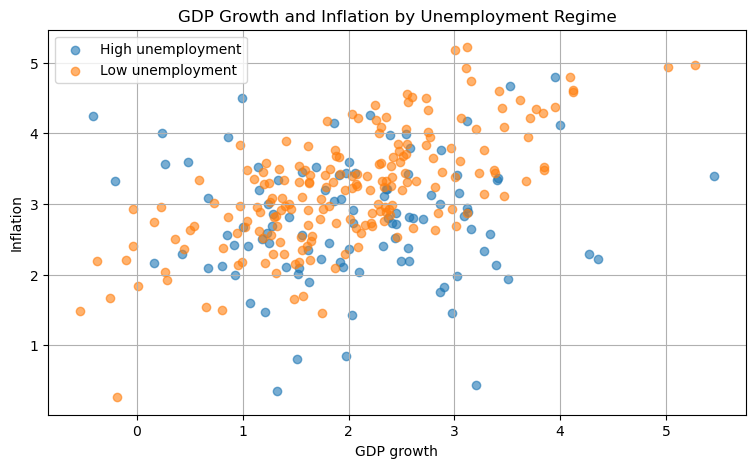

In [19]:
fig, ax = plt.subplots()
for label, group in macro.groupby("Unemployment regime"):
    ax.scatter(group["GDP growth"], group["Inflation"], alpha=0.6, label=label)
ax.set_title("GDP Growth and Inflation by Unemployment Regime")
ax.set_xlabel("GDP growth")
ax.set_ylabel("Inflation")
ax.legend()
plt.show()

# 5. Partial Correlation

Correlation between $X$ and $Y$ may be driven by a third variable $Z$. Partial correlation measures the relationship between $X$ and $Y$ after removing the linear effect of $Z$ from both variables.

One way to compute partial correlation is:

1. Regress $X$ on $Z$ and save the residuals $\hat{u}_X$.
2. Regress $Y$ on $Z$ and save the residuals $\hat{u}_Y$.
3. Compute the correlation between $\hat{u}_X$ and $\hat{u}_Y$.

That is,

$$
r_{XY \cdot Z} = \operatorname{Corr}(\hat{u}_X, \hat{u}_Y).
$$

This is a first glimpse of the logic of multiple regression: we often want to know whether a relationship remains after controlling for other variables.

In [21]:
# Simulate data in which X and Y are both related to Z
n = 500
Z = rng.normal(0, 1, n)
X = 2.0 * Z + rng.normal(0, 1, n)
Y = -1.5 * Z + rng.normal(0, 1, n)

partial_data = pd.DataFrame({"X": X, "Y": Y, "Z": Z})

raw_corr = partial_data[["X", "Y"]].corr().iloc[0, 1]
print(f"Raw correlation between X and Y: {raw_corr:.3f}")

Raw correlation between X and Y: -0.726


In [23]:
def residualize(y, X_control):
    """Return residuals from regressing y on a constant and X_control."""
    X_design = np.column_stack([np.ones(len(X_control)), X_control])
    beta_hat = np.linalg.lstsq(X_design, y, rcond=None)[0]
    fitted = X_design @ beta_hat
    return y - fitted

x_resid = residualize(partial_data["X"].to_numpy(), partial_data["Z"].to_numpy())
y_resid = residualize(partial_data["Y"].to_numpy(), partial_data["Z"].to_numpy())

partial_corr = np.corrcoef(x_resid, y_resid)[0, 1]
print(f"Partial correlation between X and Y controlling for Z: {partial_corr:.3f}")

Partial correlation between X and Y controlling for Z: -0.011


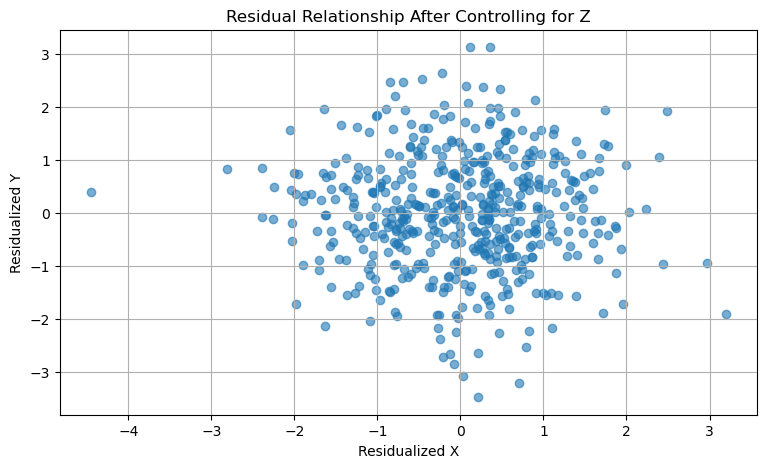

In [25]:
plt.scatter(x_resid, y_resid, alpha=0.6)
plt.title("Residual Relationship After Controlling for Z")
plt.xlabel("Residualized X")
plt.ylabel("Residualized Y")
plt.show()

# 6. Regression as a Conditional Relationship

Simple linear regression models the conditional mean of $Y$ given $X$:

$$
Y_i = \beta_0 + \beta_1 X_i + \varepsilon_i.
$$

The ordinary least squares estimator chooses $\hat{\beta}_0$ and $\hat{\beta}_1$ to minimize the sum of squared residuals:

$$
\min_{\beta_0,\beta_1} \sum_{i=1}^n \left(Y_i - \beta_0 - \beta_1 X_i\right)^2.
$$

For simple regression, the slope can be written as

$$
\hat{\beta}_1 = \frac{\widehat{\operatorname{Cov}}(X,Y)}{\widehat{\operatorname{Var}}(X)}.
$$

The intercept is

$$
\hat{\beta}_0 = \bar{Y} - \hat{\beta}_1 \bar{X}.
$$

This shows the deep connection between covariance and regression.

In [27]:
# Generate synthetic regression data
n = 500
X = rng.uniform(0, 2, n)
epsilon = rng.normal(0, 0.8, n)
Y = 4 + 3 * X + epsilon

# Closed-form OLS using matrix algebra
X_design = np.column_stack([np.ones(n), X])
beta_hat = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ Y

print(f"Estimated intercept: {beta_hat[0]:.3f}")
print(f"Estimated slope: {beta_hat[1]:.3f}")

Estimated intercept: 4.051
Estimated slope: 2.973


In [29]:
# Equivalent covariance-based slope
beta_1_cov = np.cov(X, Y, ddof=1)[0, 1] / np.var(X, ddof=1)
beta_0_cov = Y.mean() - beta_1_cov * X.mean()

print(f"Covariance-based intercept: {beta_0_cov:.3f}")
print(f"Covariance-based slope: {beta_1_cov:.3f}")

Covariance-based intercept: 4.051
Covariance-based slope: 2.973


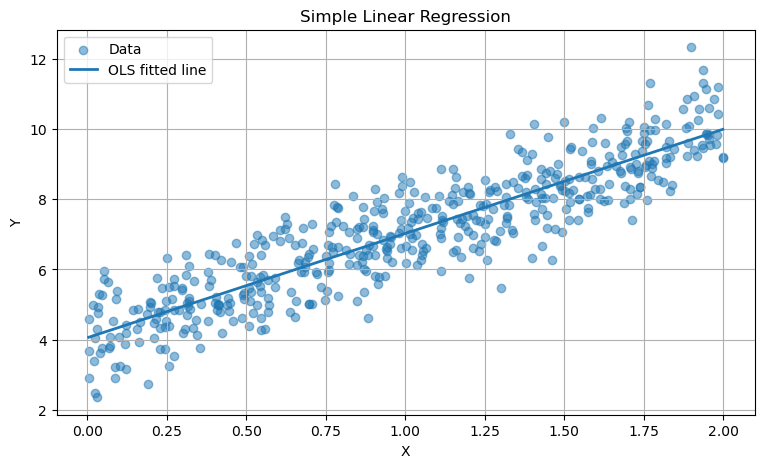

In [31]:
# Plot fitted regression line
x_line = np.linspace(X.min(), X.max(), 100)
y_line = beta_hat[0] + beta_hat[1] * x_line

plt.scatter(X, Y, alpha=0.5, label="Data")
plt.plot(x_line, y_line, linewidth=2, label="OLS fitted line")
plt.title("Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

## Residuals

The residual for observation $i$ is

$$
\hat{\varepsilon}_i = Y_i - \hat{Y}_i.
$$

A residual is the part of $Y_i$ that is not explained by the fitted linear relationship with $X_i$.

Regression is not merely drawing a line through a scatter plot. It is a way of decomposing an outcome into a systematic component and an unexplained component:

$$
Y_i = \hat{Y}_i + \hat{\varepsilon}_i.
$$

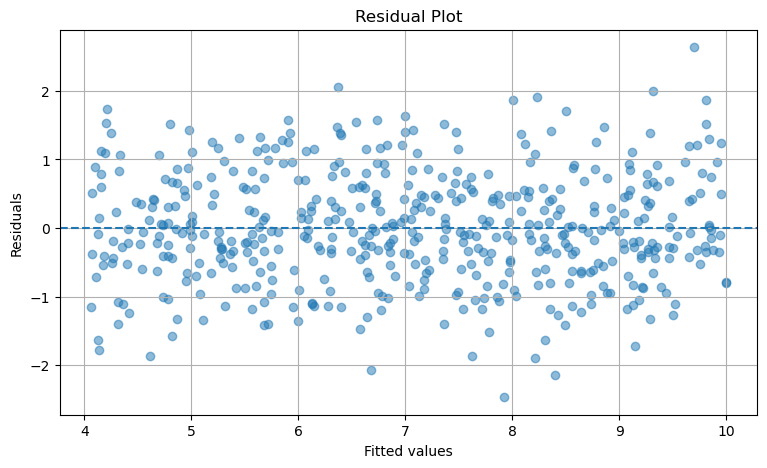

In [33]:
fitted = X_design @ beta_hat
residuals = Y - fitted

fig, ax = plt.subplots()
ax.scatter(fitted, residuals, alpha=0.5)
ax.axhline(0, linestyle="--")
ax.set_title("Residual Plot")
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
plt.show()

# 7. When Correlation is Not Enough: Nonlinear Dependence

Correlation is a measure of linear dependence. Two variables can have a strong nonlinear relationship even when their correlation is close to zero.

Correlation between X and X^2 plus noise: 0.053


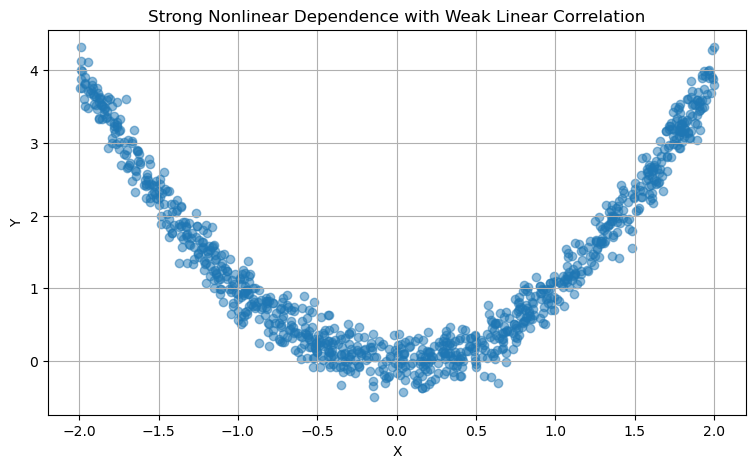

In [35]:
# Nonlinear dependence with near-zero linear correlation
X_nonlinear = rng.uniform(-2, 2, 1000)
Y_nonlinear = X_nonlinear**2 + rng.normal(0, 0.2, 1000)

corr_nonlinear = np.corrcoef(X_nonlinear, Y_nonlinear)[0, 1]
print(f"Correlation between X and X^2 plus noise: {corr_nonlinear:.3f}")

plt.scatter(X_nonlinear, Y_nonlinear, alpha=0.5)
plt.title("Strong Nonlinear Dependence with Weak Linear Correlation")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# 8. Copulas: Modeling Dependence Separately from Marginals

A copula is a function that links marginal distributions into a joint distribution. Copulas are useful because they separate two problems:

1. What is the distribution of each variable individually?
2. How do the variables depend on one another jointly?

Sklar’s Theorem says that for random variables $X_1, X_2, \ldots, X_n$ with joint cumulative distribution function $F$ and marginal CDFs $F_1, F_2, \ldots, F_n$, there exists a copula $C$ such that

$$
F(x_1,x_2,\ldots,x_n)
= C\left(F_1(x_1),F_2(x_2),\ldots,F_n(x_n)\right).
$$

If the marginal distributions are continuous, the copula is unique.

In finance, copulas are used to model joint asset returns, credit defaults, and tail dependence. Their misuse can be dangerous, but the basic idea is valuable: dependence is not fully summarized by ordinary correlation.

## Gaussian Copula Simulation

A Gaussian copula uses a multivariate normal dependence structure. The simulation steps are:

1. Draw correlated normal variables $(Z_1,Z_2)$.
2. Convert them to uniforms using the normal CDF:

$$
U_j = \Phi(Z_j).
$$

3. Convert uniforms into desired marginal distributions using inverse CDFs:

$$
X_j = F_j^{-1}(U_j).
$$

This lets us keep one dependence structure while choosing different marginal distributions.

Correlation after imposing Gaussian copula dependence: 0.639


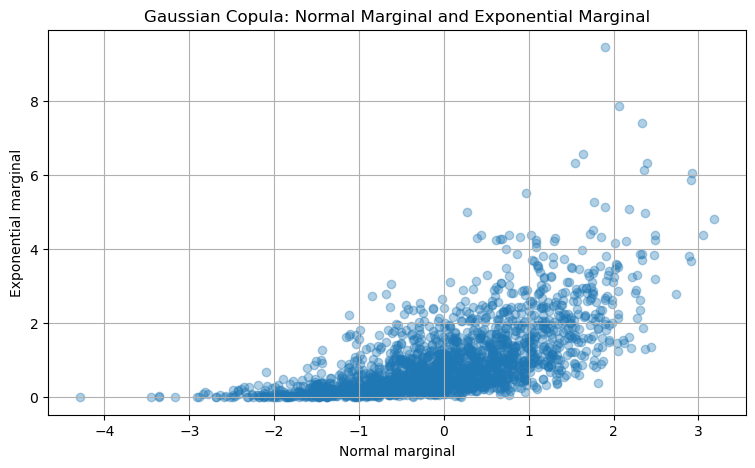

In [37]:
# Gaussian copula example with normal and exponential marginals
n = 2000
rho = 0.70
corr_matrix = np.array([[1, rho], [rho, 1]])

Z = rng.multivariate_normal(mean=[0, 0], cov=corr_matrix, size=n)
U = stats.norm.cdf(Z)

# Choose different marginals
X_copula = stats.norm.ppf(U[:, 0], loc=0, scale=1)
Y_copula = stats.expon.ppf(U[:, 1], scale=1)

print(f"Correlation after imposing Gaussian copula dependence: {np.corrcoef(X_copula, Y_copula)[0, 1]:.3f}")

plt.scatter(X_copula, Y_copula, alpha=0.35)
plt.title("Gaussian Copula: Normal Marginal and Exponential Marginal")
plt.xlabel("Normal marginal")
plt.ylabel("Exponential marginal")
plt.show()

## Tail Dependence and the $t$ Copula

A Gaussian copula has limited tail dependence. A $t$ copula can generate more joint extreme observations. That is important in finance because assets often become more dependent in bad states of the world.

A simple way to simulate a $t$ copula is to draw correlated normal shocks and divide by a common chi-square scaling factor:

$$
T = \frac{Z}{\sqrt{W/\nu}},
$$

where $W \sim \chi^2_\nu$ and $\nu$ is the degrees-of-freedom parameter. Smaller $\nu$ produces heavier tails.

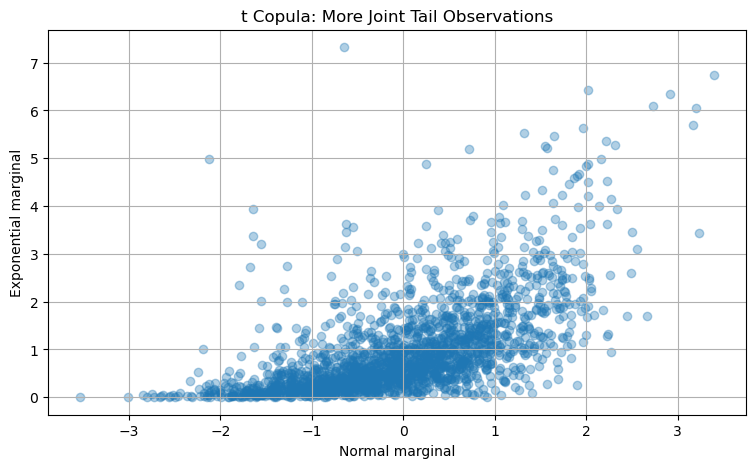

In [39]:
# t-copula style simulation
n = 2000
nu = 4
rho = 0.70
corr_matrix = np.array([[1, rho], [rho, 1]])

Z = rng.multivariate_normal(mean=[0, 0], cov=corr_matrix, size=n)
W = rng.chisquare(df=nu, size=n)
T = Z / np.sqrt(W[:, None] / nu)
U_t = stats.t.cdf(T, df=nu)

X_t = stats.norm.ppf(U_t[:, 0], loc=0, scale=1)
Y_t = stats.expon.ppf(U_t[:, 1], scale=1)

plt.scatter(X_t, Y_t, alpha=0.35)
plt.title("t Copula: More Joint Tail Observations")
plt.xlabel("Normal marginal")
plt.ylabel("Exponential marginal")
plt.show()

# 9. Summary

This lecture introduced the empirical study of relationships between variables.

Key ideas:

- Covariance measures co-movement in original units.
- Correlation standardizes covariance and lies between $-1$ and $1$.
- Conditional covariance and conditional correlation can differ across groups or states.
- Partial correlation removes the linear effect of a control variable before measuring association.
- Regression formalizes conditional relationships and connects directly to covariance.
- Correlation can miss nonlinear dependence.
- Copulas separate marginal distributions from the dependence structure.

The next lecture will develop regression more systematically. We will study fitted values, residuals, least squares, goodness of fit, standard errors, and hypothesis tests for regression coefficients.

# Practice Problems

1. Generate two variables $X$ and $Y$ such that $Y = 5 - 2X + \varepsilon$. Estimate their covariance, correlation, and simple regression slope.

2. Simulate two asset returns whose correlation is $0.2$ in normal times and $0.8$ in crisis times. Compare unconditional and conditional correlations.

3. Generate three variables such that $X$ and $Y$ are correlated only because both depend on $Z$. Compute the raw correlation and the partial correlation controlling for $Z$.

4. Create a nonlinear relationship such as $Y = X^3 + \varepsilon$. Compare a scatter plot with the Pearson correlation.

5. Explain in words why a copula can be useful when the marginal distributions are non-normal.